In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

RELATIVE = Path(
    "outputs/backward_pde_diagnostics/ah_smoothed_robustness"
)

ROOT = next(
    (
        p for p in [Path.cwd(), *Path.cwd().parents]
        if (p / RELATIVE / "audit.json").is_file()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Open this notebook inside local-vol-spx."
    )

STUDY = ROOT / RELATIVE
audit = json.loads((STUDY / "audit.json").read_text())

if audit.get("status") != "completed":
    raise ValueError("The study did not finish.")

for name, expected in audit["input_sha256"].items():
    path = Path(name)
    path = path if path.is_absolute() else ROOT / path

    if hashlib.sha256(path.read_bytes()).hexdigest() != expected:
        raise ValueError(f"Study input changed: {path}")


def read_csv(name):
    return pd.read_csv(STUDY / name)


def show(frame):
    display(
        HTML(
            frame.to_html(
                index=False,
                float_format=lambda x: f"{x:.7g}",
                na_rep="",
            )
        )
    )


REFERENCE = audit["reference_case"]
CASES = [c["case"] for c in audit["cases"]]
WINDOWS = audit["spot_log_windows"]

contracts = read_csv("contracts.csv")
coverage = read_csv("quote_coverage.csv")
curves = {
    case: read_csv(f"curves_{case}.csv")
    for case in CASES
}

print(
    f"Radius: {audit['radius_in_log_state']}; "
    f"reference: {REFERENCE}"
)
print(
    "Numerical reference only. "
    "Wing scenarios change the diffusion."
)

show(pd.DataFrame(audit["cases"]))
show(coverage)

Radius: 0.0005; reference: native_16000
Numerical reference only. Wing scenarios change the diffusion.


case,native_intervals,width,pde_intervals,steps_per_day,state_shift,wing_vol_factor
native_4000,4000,0.5,16000,128,0,1
native_8000,8000,0.5,16000,128,0,1
native_16000,16000,0.5,16000,128,0,1
pde_coarse,16000,0.5,8000,128,0,1
time_coarse,16000,0.5,16000,64,0,1
half_cell_shift,16000,0.5,16000,128,3.125e-05,1
domain_wide,16000,0.75,24000,128,0,1
wing_0.8,16000,0.5,16000,128,0,0.8
wing_1.2,16000,0.5,16000,128,0,1.2


days,observed_min_y,observed_max_y
4,-0.09908749,0.02492441
7,-0.09957521,0.04791696
11,-0.09742523,0.06020371
13,-0.0977961,0.05983284
21,-0.09889088,0.09956006
28,-0.09971183,0.09873911
35,-0.09822007,0.09779482
42,-0.09905892,0.09695597
56,-0.09138767,0.09494191
60,-0.09884621,0.09972608


In [2]:
KEYS = ["days", "log_strike", "spot_log_change"]
FIELDS = ["price", "delta", "gamma"]

ref = curves[REFERENCE][
    KEYS + ["spot"] + FIELDS
].rename(
    columns={
        c: f"{c}_ref"
        for c in ["spot"] + FIELDS
    }
)

differences = {}
rows = []

for case, frame in curves.items():
    aligned = frame.merge(
        ref,
        on=KEYS,
        how="outer",
        validate="one_to_one",
        indicator=True,
    )

    if not aligned["_merge"].eq("both").all():
        raise ValueError(
            f"Contract or spot samples differ: {case}"
        )

    if not np.allclose(
        aligned["spot"],
        aligned["spot_ref"],
        rtol=0,
        atol=1e-8,
    ):
        raise ValueError(f"Physical spots differ: {case}")

    numeric = FIELDS + [f"{f}_ref" for f in FIELDS]

    if not np.isfinite(aligned[numeric]).all().all():
        raise ValueError(
            f"Non-finite prices or Greeks: {case}"
        )

    for field in FIELDS:
        aligned[f"change_{field}"] = (
            aligned[field] - aligned[f"{field}_ref"]
        )

    differences[case] = aligned

    for (day, strike_y), curve in aligned.groupby(
        ["days", "log_strike"]
    ):
        bounds = coverage[
            np.isclose(
                coverage["days"],
                day,
                rtol=0,
                atol=1e-8,
            )
        ]

        if len(bounds) != 1:
            raise ValueError(
                f"Missing quote coverage for {day} days."
            )

        bounds = bounds.iloc[0]

        for window in WINDOWS:
            sample = curve[
                curve["spot_log_change"].abs()
                <= window + 1e-12
            ]

            if sample.empty:
                raise ValueError("Empty spot window.")

            row = {
                "case": case,
                "days": day,
                "log_strike": strike_y,
                "window": window,
                "group": (
                    "central"
                    if abs(strike_y) <= 0.02 + 1e-12
                    else "outer"
                ),
                "within_quote_range_at_spot": bool(
                    bounds.observed_min_y
                    <= strike_y
                    <= bounds.observed_max_y
                ),
            }

            for field in FIELDS:
                peak = sample.loc[
                    sample[f"change_{field}"].abs().idxmax()
                ]

                row[f"max_{field}_change"] = abs(
                    peak[f"change_{field}"]
                )
                row[f"{field}_peak_spot_y"] = (
                    peak["spot_log_change"]
                )

            row["negative_gamma_samples"] = int(
                (sample["gamma"] < -1e-8).sum()
            )

            rows.append(row)

review = pd.DataFrame(rows)

summary = review.groupby(
    ["case", "group", "window"],
    as_index=False,
).agg(
    max_price_change=("max_price_change", "max"),
    max_delta_change=("max_delta_change", "max"),
    max_gamma_change=("max_gamma_change", "max"),
    negative_gamma_samples=("negative_gamma_samples", "sum"),
)

saved = read_csv("conditional_sensitivity.csv")

for row in saved.itertuples(index=False):
    sample = review[
        review.case.eq(row.case)
        & np.isclose(
            review.window,
            row.spot_log_half_width,
        )
    ]

    for field in FIELDS:
        if not np.isclose(
            sample[f"max_{field}_change"].max(),
            getattr(row, f"max_{field}_change"),
            rtol=1e-8,
            atol=1e-10,
        ):
            raise ValueError(
                "Derived maxima disagree with the saved study."
            )

show(
    summary[
        summary.case.ne(REFERENCE)
        & np.isclose(summary.window, 0.01)
    ]
)

case,group,window,max_price_change,max_delta_change,max_gamma_change,negative_gamma_samples
domain_wide,central,0.01,0.1082249,0.006332323,0.0002505189,0
domain_wide,outer,0.01,0.2441535,0.01403621,0.0005398778,0
half_cell_shift,central,0.01,0.000504065,3.309214e-05,0.0002380671,0
half_cell_shift,outer,0.01,0.0003080181,1.13347e-05,6.902937e-05,0
native_4000,central,0.01,0.3864755,0.0148546,0.002766853,0
native_4000,outer,0.01,0.3438669,0.013183,0.0009485475,0
native_8000,central,0.01,0.1345931,0.005193432,0.001198263,0
native_8000,outer,0.01,0.1194367,0.004608177,0.0004011099,0
pde_coarse,central,0.01,0.001076009,0.0001016324,0.0001372399,0
pde_coarse,outer,0.01,0.0006737804,3.291603e-05,4.165163e-05,0


In [3]:
VIEW_WINDOW = 0.01
VIEW_GROUP = "central"

SCENARIOS = [
    c for c in CASES
    if c == "domain_wide" or c.startswith("wing_")
]

selected = review[
    np.isclose(review.window, VIEW_WINDOW)
    & review.group.eq(VIEW_GROUP)
    & review.case.isin(SCENARIOS)
]

for field in FIELDS:
    print(
        f"Maximum absolute {field} change "
        f"within log-spot ±{VIEW_WINDOW:g}"
    )

    show(
        selected.pivot(
            index=["days", "log_strike"],
            columns="case",
            values=f"max_{field}_change",
        ).reset_index()
    )

locations = []

for case, group in selected.groupby("case"):
    for field in FIELDS:
        peak = group.loc[
            group[f"max_{field}_change"].idxmax()
        ]

        locations.append(
            {
                "case": case,
                "metric": field,
                "days": peak.days,
                "log_strike": peak.log_strike,
                "spot_log_change": peak[
                    f"{field}_peak_spot_y"
                ],
                "absolute_change": peak[
                    f"max_{field}_change"
                ],
                "within_quote_range_at_spot": (
                    peak.within_quote_range_at_spot
                ),
            }
        )

locations = pd.DataFrame(locations)
show(locations)

Maximum absolute price change within log-spot ±0.01


case,days,log_strike,domain_wide,wing_0.8,wing_1.2
,4,-0.02,0.009955887,0.01179533,0.007047984
,4,0,2.527878e-06,8.26316e-05,8.208761e-05
,4,0.02,2.4738e-12,0.1493478,0.1332225
,35,-0.02,0.07935899,0.06891998,0.0534295
,35,0,0.0328711,0.1152317,0.1021081
,35,0.02,0.008518899,0.2253808,0.1998742
,60,-0.02,0.1082249,0.181656,0.1413876
,60,0,0.057208,0.1720599,0.1530216
,60,0.02,0.02433649,0.2564412,0.2293353


Maximum absolute delta change within log-spot ±0.01


case,days,log_strike,domain_wide,wing_0.8,wing_1.2
,4,-0.02,0.0008020847,0.0006184169,0.0003516542
,4,0,3.232394e-07,1.157109e-05,1.13847e-05
,4,0.02,6.128431e-13,0.01089043,0.009436479
,35,-0.02,0.004755513,0.003847361,0.003318102
,35,0,0.002014887,0.007878746,0.00678426
,35,0.02,0.0005395852,0.01533845,0.01321935
,60,-0.02,0.006332323,0.006622475,0.005731531
,60,0,0.003391255,0.01088506,0.009422582
,60,0.02,0.001465818,0.01714144,0.01490883


Maximum absolute gamma change within log-spot ±0.01


case,days,log_strike,domain_wide,wing_0.8,wing_1.2
,4,-0.02,4.964873e-05,1.887479e-05,1.00831e-05
,4,0,3.590657e-08,1.314691e-06,1.277365e-06
,4,0.02,8.586201e-12,0.0005196394,0.0004358254
,35,-0.02,0.0001951932,0.0001863429,0.0001556495
,35,0,8.570933e-05,0.0003591659,0.0002995351
,35,0.02,2.41447e-05,0.0006868496,0.0005736451
,60,-0.02,0.0002505189,0.0003408714,0.0002860281
,60,0,0.0001369993,0.000502448,0.0004215765
,60,0.02,6.074051e-05,0.000768078,0.0006476892


case,metric,days,log_strike,spot_log_change,absolute_change,within_quote_range_at_spot
domain_wide,price,60,-0.02,-0.01,0.1082249,True
domain_wide,delta,60,-0.02,-0.01,0.006332323,True
domain_wide,gamma,60,-0.02,-0.01,0.0002505189,True
wing_0.8,price,60,0.02,0.01,0.2564412,True
wing_0.8,delta,60,0.02,0.01,0.01714144,True
wing_0.8,gamma,60,0.02,0.0089,0.000768078,True
wing_1.2,price,60,0.02,0.01,0.2293353,True
wing_1.2,delta,60,0.02,0.01,0.01490883,True
wing_1.2,gamma,60,0.02,0.0088,0.0006476892,True


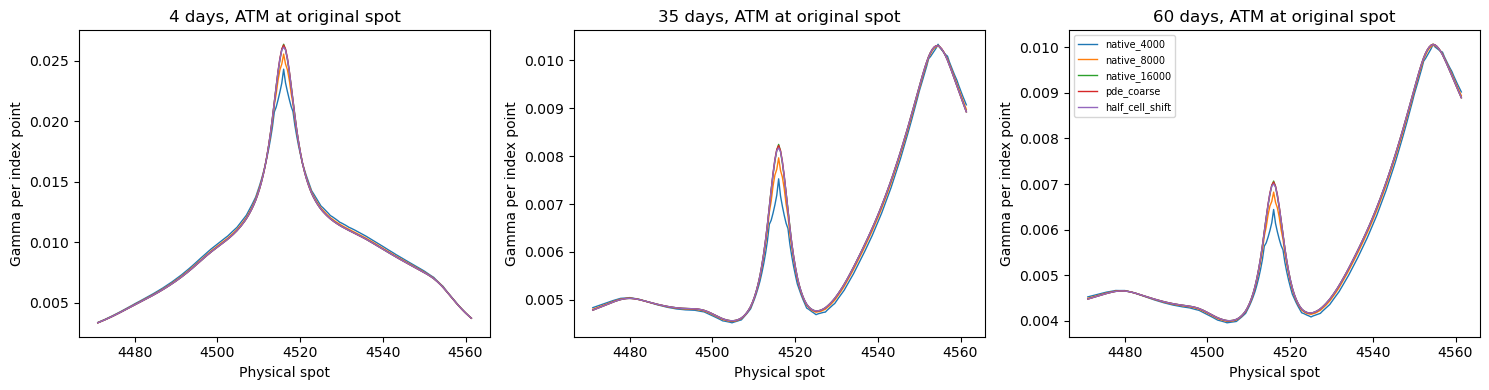

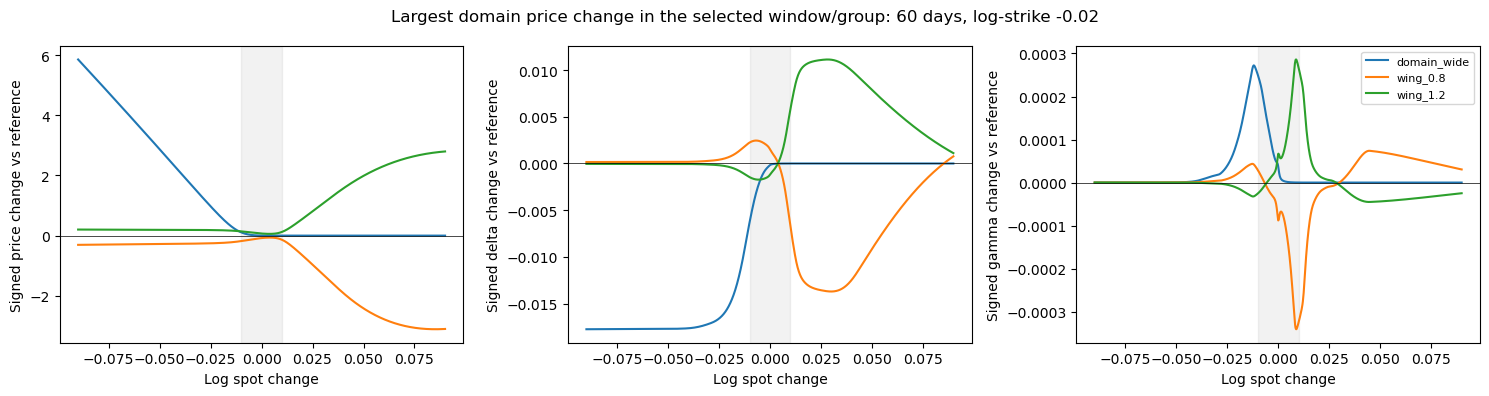

In [4]:
days = sorted(contracts["days"].unique())

fig, axes = plt.subplots(
    1,
    len(days),
    figsize=(5 * len(days), 4),
    squeeze=False,
)

numerical = [
    c for c in CASES
    if c.startswith("native_")
    or c in ("pde_coarse", "half_cell_shift")
]

for ax, day in zip(axes[0], days):
    for case in numerical:
        frame = curves[case]

        sample = frame[
            np.isclose(frame.days, day)
            & np.isclose(frame.log_strike, 0)
            & (
                frame.spot_log_change.abs()
                <= 0.01 + 1e-12
            )
        ]

        ax.plot(
            sample.spot,
            sample.gamma,
            label=case,
            linewidth=1,
        )

    ax.set(
        title=f"{day:g} days, ATM at original spot",
        xlabel="Physical spot",
        ylabel="Gamma per index point",
    )

axes[0, -1].legend(fontsize=7)
fig.tight_layout()
plt.show()

worst_domain = selected[
    selected.case.eq("domain_wide")
].sort_values(
    "max_price_change",
    ascending=False,
).iloc[0]

PLOT_DAYS = float(worst_domain.days)
PLOT_LOG_STRIKE = float(worst_domain.log_strike)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, field in zip(axes, FIELDS):
    for case in SCENARIOS:
        frame = differences[case]

        sample = frame[
            np.isclose(frame.days, PLOT_DAYS)
            & np.isclose(
                frame.log_strike,
                PLOT_LOG_STRIKE,
            )
        ].sort_values("spot_log_change")

        ax.plot(
            sample.spot_log_change,
            sample[f"change_{field}"],
            label=case,
        )

    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvspan(
        -VIEW_WINDOW,
        VIEW_WINDOW,
        color="grey",
        alpha=0.1,
    )

    ax.set(
        xlabel="Log spot change",
        ylabel=f"Signed {field} change vs reference",
    )

axes[-1].legend(fontsize=8)

fig.suptitle(
    "Largest domain price change in the selected window/group: "
    f"{PLOT_DAYS:g} days, "
    f"log-strike {PLOT_LOG_STRIKE:+g}"
)

fig.tight_layout()
plt.show()

In [5]:
shape_fields = [
    "increasing_prices",
    "vertical_spread_violations",
    "negative_butterflies",
    "intrinsic_shortfalls",
    "upper_bound_excesses",
    "calendar_violations",
]

full_shapes = read_csv("forward_shapes.csv")
window_shapes = read_csv("forward_window_shapes.csv")
butterflies = read_csv("forward_butterfly_locations.csv")

if int(full_shapes["negative_butterflies"].sum()) != len(
    butterflies
):
    raise ValueError(
        "Butterfly locations do not match the recorded flag count."
    )

print("Full-domain forward flags")
show(
    full_shapes.groupby(
        "case",
        as_index=False,
    )[shape_fields].sum()
)

print("Forward flags inside log-strike ±0.09")
show(
    window_shapes[
        np.isclose(
            window_shapes.log_strike_half_width,
            0.09,
        )
    ].groupby(
        "case",
        as_index=False,
    )[shape_fields].sum()
)

if butterflies.empty:
    butterfly_summary = pd.DataFrame(
        columns=[
            "case",
            "days",
            "flags",
            "minimum_y",
            "maximum_y",
            "minimum_slope_change",
            "largest_breach_in_tolerance_units",
        ]
    )

    print("No recorded butterfly flags.")

else:
    butterfly_summary = butterflies.groupby(
        ["case", "days"],
        as_index=False,
    ).agg(
        flags=("log_moneyness", "size"),
        minimum_y=("log_moneyness", "min"),
        maximum_y=("log_moneyness", "max"),
        minimum_slope_change=(
            "butterfly_slope_change",
            "min",
        ),
    )

    tolerance = audit["shape_tolerances"][
        "butterfly_slope_change"
    ]

    butterfly_summary[
        "largest_breach_in_tolerance_units"
    ] = (
        -butterfly_summary.minimum_slope_change
        / tolerance
    )

    show(butterfly_summary)

    print(
        "Inspect magnitudes and locations; "
        "this table does not establish their cause."
    )

print("Underlying AH prices before the diffusion change")
show(read_csv("frozen_proxy_quote_fit.csv"))

print("Changed-diffusion quote fit")
show(read_csv("diffusion_quote_fit.csv"))

print("Maximum forward/backward difference, index points")
show(
    read_csv("forward_backward.csv").groupby(
        "case",
        as_index=False,
    ).agg(
        max_difference=(
            "forward_minus_backward",
            lambda x: x.abs().max(),
        )
    )
)

Full-domain forward flags


case,increasing_prices,vertical_spread_violations,negative_butterflies,intrinsic_shortfalls,upper_bound_excesses,calendar_violations
domain_wide,0,0,94,0,0,0
native_16000,0,0,0,0,0,0
native_4000,0,0,0,0,0,0
native_8000,0,0,0,0,0,0
wing_0.8,0,0,0,0,0,0
wing_1.2,0,0,1,0,0,0


Forward flags inside log-strike ±0.09


case,increasing_prices,vertical_spread_violations,negative_butterflies,intrinsic_shortfalls,upper_bound_excesses,calendar_violations
domain_wide,0,0,0,0,0,0
native_16000,0,0,0,0,0,0
native_4000,0,0,0,0,0,0
native_8000,0,0,0,0,0,0
wing_0.8,0,0,0,0,0,0
wing_1.2,0,0,0,0,0,0


case,days,flags,minimum_y,maximum_y,minimum_slope_change,largest_breach_in_tolerance_units
domain_wide,4,94,-0.7479375,-0.575625,-1.862632e-08,1.862632
wing_1.2,4,1,-0.47125,-0.47125,-1.066169e-08,1.066169


...

native_intervals,rms_half_spreads,outside_bands,max_quote_change_vs_input
4000,0.6915431,141,0.006114797
8000,0.691708,140,0
16000,0.6916183,141,0.002054974


Changed-diffusion quote fit


case,rms_half_spreads,outside_bands,max_quote_change_vs_reference
native_4000,0.738795,175,0.006260061
native_8000,0.7375641,176,0.003364615
native_16000,0.7412943,176,0
domain_wide,0.7472491,180,0.005141718
wing_0.8,1.298704,294,1.027173
wing_1.2,1.273044,353,0.8756742


Maximum forward/backward difference, index points


case,max_difference
domain_wide,4.117567e-05
native_16000,4.117586e-05
native_4000,2.680968e-05
native_8000,3.293953e-05
wing_0.8,4.11759e-05
wing_1.2,4.117584e-05


In [6]:
REVIEW = STUDY / "notebook_review"
REVIEW.mkdir(exist_ok=True)

for name, frame in {
    "contract_sensitivity.csv": review,
    "group_sensitivity.csv": summary,
    "selected_peak_locations.csv": locations,
    "butterfly_summary.csv": butterfly_summary,
}.items():
    frame.to_csv(REVIEW / name, index=False)

print(f"Review tables saved to {REVIEW}")
print("No model files changed and no candidate promoted.")

Review tables saved to /Users/pranayvij/GitHub/local-vol-spx/outputs/backward_pde_diagnostics/ah_smoothed_robustness/notebook_review
No model files changed and no candidate promoted.
